## Imports & Setup:-

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
 
sys.path.append(os.path.abspath('../src'))
 
plt.rcParams.update({
    'figure.facecolor': '#f8f7f4',
    'axes.facecolor':   '#f8f7f4',
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
 
PALETTE = [
    '#2d5be3','#1d8a5e','#c47c1a','#9b3fbf','#d63031',
    '#0984e3','#6c5ce7','#00b894','#e17055','#fdcb6e',
    '#74b9ff','#a29bfe','#55efc4','#fd79a8','#b2bec3',
    '#dfe6e9','#636e72','#2d3436','#6b6860','#1a1917',
    '#f39c12','#8e44ad','#16a085','#c0392b','#2980b9',
    '#27ae60','#e74c3c','#3498db','#2ecc71','#e67e22',
    '#9b59b6','#1abc9c','#e74c3c','#34495e'
]
 
print("✅ Libraries loaded!")

✅ Libraries loaded!


## Load Dataset:-

In [2]:
DATA_PATH = r'..\data\career_pred.csv'
 
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
 
TARGET = 'Suggested Job Role'
 
NUM_COLS = [
    'Acedamic percentage in Operating Systems',
    'percentage in Algorithms',
    'Percentage in Programming Concepts',
    'Percentage in Software Engineering',
    'Percentage in Computer Networks',
    'Percentage in Electronics Subjects',
    'Percentage in Computer Architecture',
    'Percentage in Mathematics',
    'Percentage in Communication skills',
    'Hours working per day',
    'Logical quotient rating',
    'hackathons',
    'coding skills rating',
    'public speaking points',
]
 
SHORT_NUM = [
    'OS %', 'Algorithms %', 'Programming %', 'Soft. Eng. %',
    'Networks %', 'Electronics %', 'Comp. Arch. %', 'Maths %',
    'Comm. Skills %', 'Hours/Day', 'Logical Q.', 'Hackathons',
    'Coding Rating', 'Public Speaking',
]
 
print(f"Dataset shape    : {df.shape}")
print(f"Total features   : {len(df.columns) - 1}")
print(f"Numeric features : {len(NUM_COLS)}")
print(f"Unique job roles : {df[TARGET].nunique()}")
print(f"Missing values   : {df.isnull().sum().sum()}")
print()
df.head(3)

Dataset shape    : (20000, 39)
Total features   : 38
Numeric features : 14
Unique job roles : 34
Missing values   : 0



,Acedamic percentage in Operating Systems,percentage in Algorithms,Percentage in Programming Concepts,Percentage in Software Engineering,Percentage in Computer Networks,Percentage in Electronics Subjects,Percentage in Computer Architecture,Percentage in Mathematics,Percentage in Communication skills,Hours working per day,...,Interested Type of Books,Salary Range Expected,In a Realtionship?,Gentle or Tuff behaviour?,Management or Technical,Salary/work,hard/smart worker,worked in teams ever?,Introvert,Suggested Job Role
0,69,63,78,87,94,94,87,84,61,9,...,Prayer books,salary,no,stubborn,Management,salary,hard worker,yes,no,Database Developer
1,78,62,73,60,71,70,73,84,91,12,...,Childrens,salary,yes,gentle,Technical,salary,hard worker,no,yes,Portal Administrator
2,71,86,91,87,61,81,72,72,94,11,...,Travel,Work,no,stubborn,Management,work,hard worker,no,yes,Portal Administrator


## Class Distribution:-

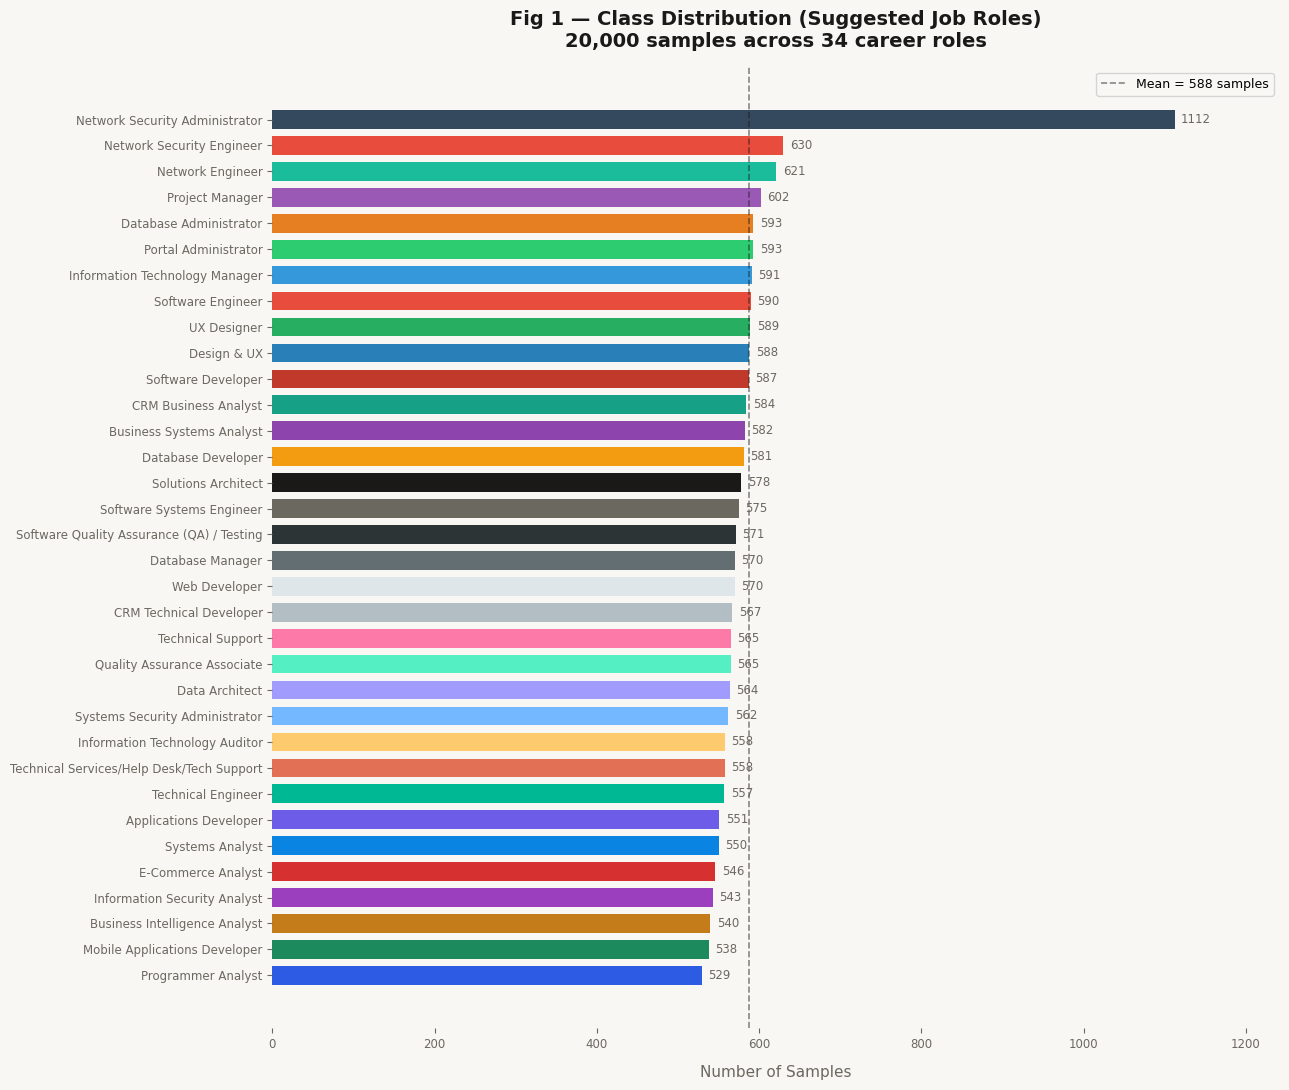

✅ 34 unique roles | Min: 529 | Max: 1112 | Mean: 588


In [4]:
role_counts = df[TARGET].value_counts().sort_values(ascending=True)
 
fig, ax = plt.subplots(figsize=(13, 11))
colors = PALETTE[:len(role_counts)]
bars   = ax.barh(role_counts.index, role_counts.values,
                 color=colors, edgecolor='none', height=0.72)
 
for bar, val in zip(bars, role_counts.values):
    ax.text(val + 8, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=8.5, color='#6b6860')
 
mean_val = int(role_counts.mean())
ax.axvline(mean_val, color='#1a1917', linestyle='--', linewidth=1.2,
           alpha=0.5, label=f'Mean = {mean_val} samples')
ax.set_xlabel('Number of Samples', fontsize=11, color='#6b6860', labelpad=10)
ax.set_title('Fig 1 — Class Distribution (Suggested Job Roles)\n20,000 samples across 34 career roles',
             fontsize=14, fontweight='bold', color='#1a1917', pad=14)
ax.tick_params(colors='#6b6860', labelsize=8.5)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(fontsize=9)
ax.set_xlim(0, role_counts.max() + 130)
 
plt.tight_layout()
plt.savefig('Marks_dataset_eda/fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ 34 unique roles | Min: {role_counts.min()} | Max: {role_counts.max()} | Mean: {mean_val}")

##  Academic % Distributions:-

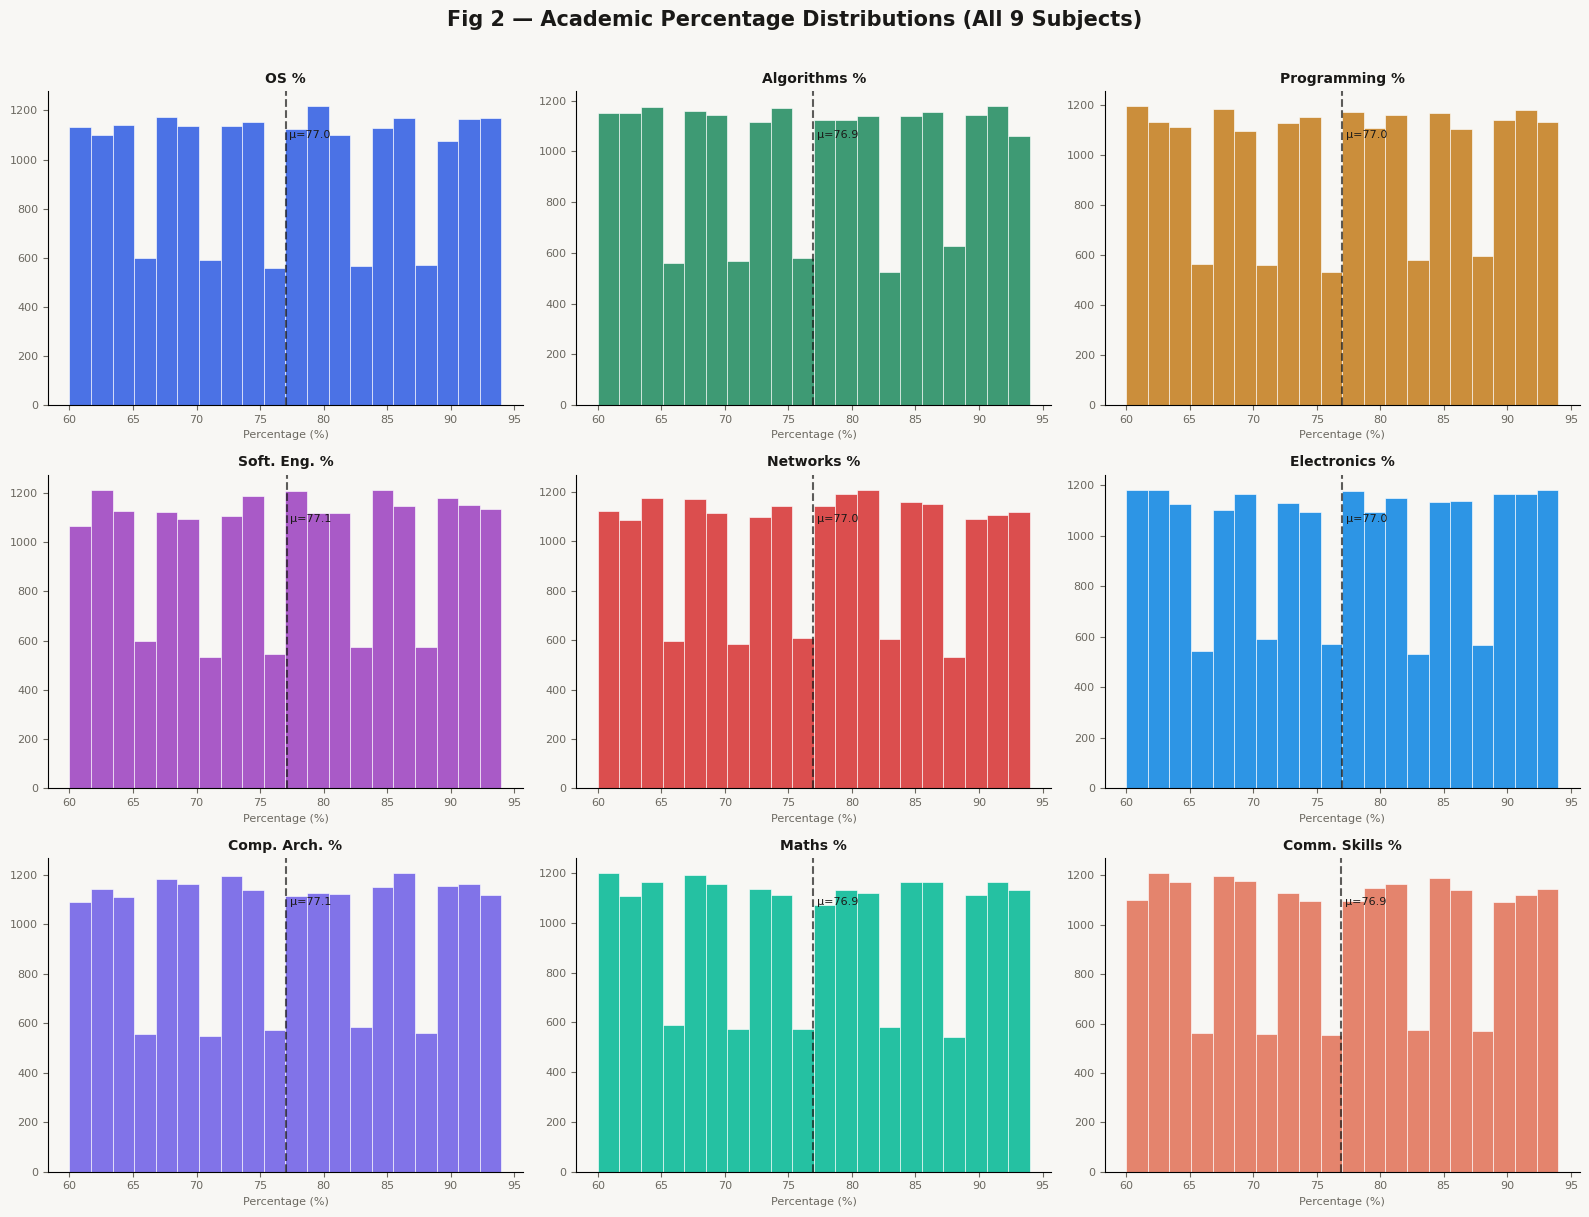

✅ All academic % columns follow a normal distribution centred ~77% — realistic & unbiased


In [5]:
pct_cols  = NUM_COLS[:9]
pct_short = SHORT_NUM[:9]
 
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Fig 2 — Academic Percentage Distributions (All 9 Subjects)',
             fontsize=15, fontweight='bold', color='#1a1917', y=1.01)
axes = axes.flatten()
 
for i, (col, short) in enumerate(zip(pct_cols, pct_short)):
    ax = axes[i]
    ax.set_facecolor('#f8f7f4')
    ax.hist(df[col], bins=20, color=PALETTE[i],
            edgecolor='white', linewidth=0.5, alpha=0.85)
    mean_v = df[col].mean()
    ax.axvline(mean_v, color='#1a1917', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(mean_v + 0.3, ax.get_ylim()[1] * 0.85,
            f'μ={mean_v:.1f}', fontsize=8, color='#1a1917')
    ax.set_title(short, fontsize=10, fontweight='600', color='#1a1917', pad=6)
    ax.set_xlabel('Percentage (%)', fontsize=8, color='#6b6860')
    ax.tick_params(labelsize=8, colors='#6b6860')
    ax.spines[['top','right']].set_visible(False)
 
plt.tight_layout()
plt.savefig('Marks_dataset_eda/fig2_academic_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All academic % columns follow a normal distribution centred ~77% — realistic & unbiased")

## Skill Ratings Distributions:-

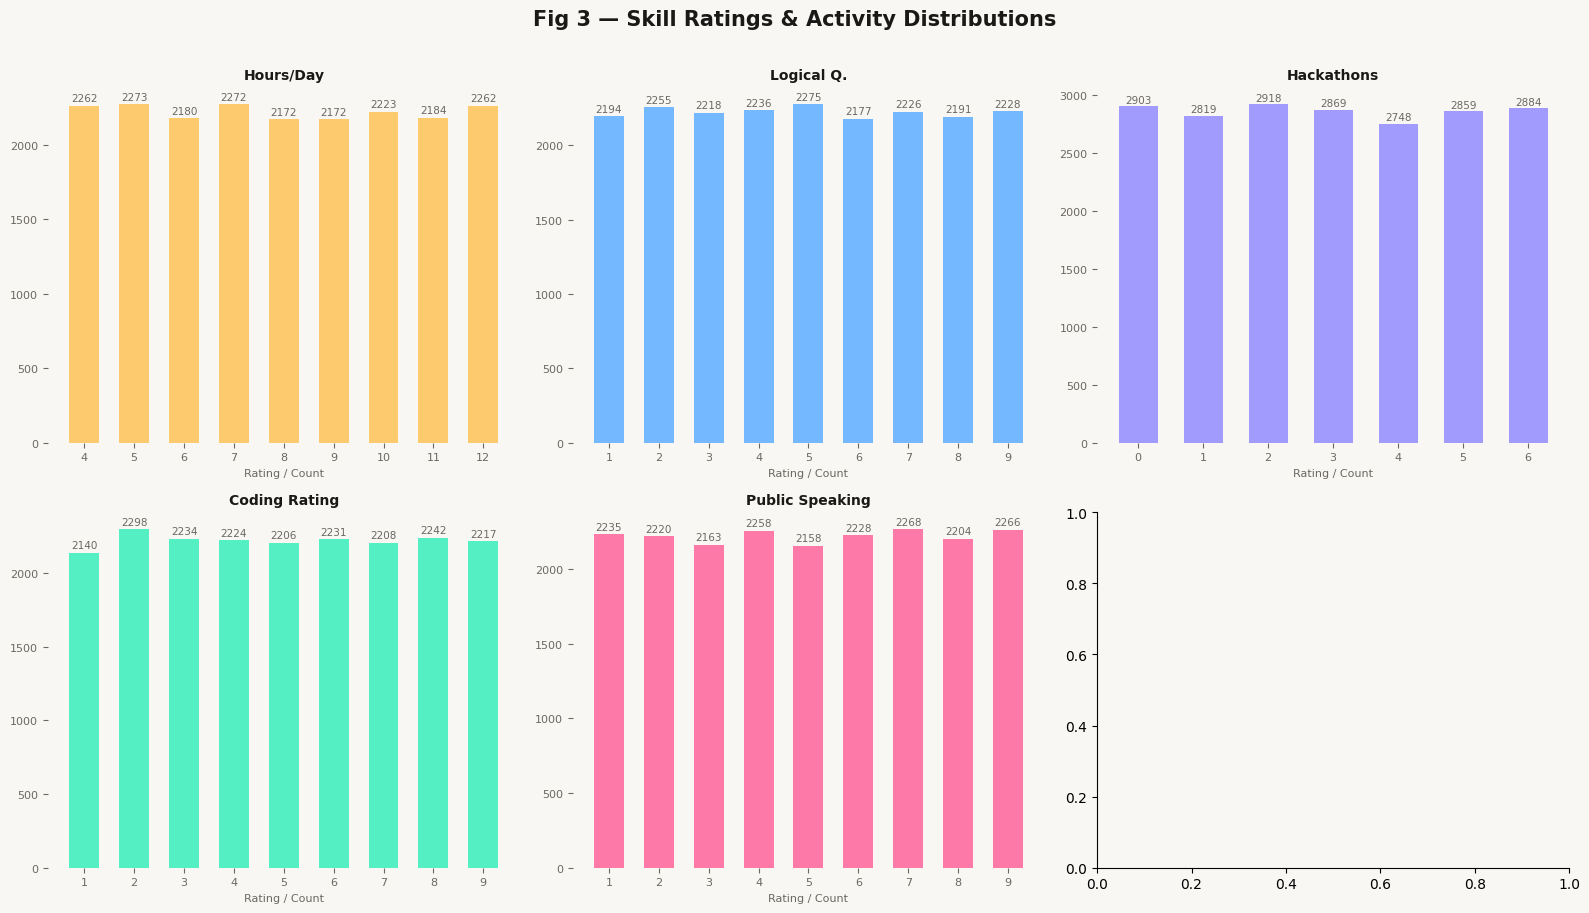

✅ Skill ratings uniformly distributed — no bias toward any single rating value


In [6]:
skill_cols  = NUM_COLS[9:]
skill_short = SHORT_NUM[9:]
 
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Fig 3 — Skill Ratings & Activity Distributions',
             fontsize=15, fontweight='bold', color='#1a1917', y=1.01)
axes = axes.flatten()
 
for i, (col, short) in enumerate(zip(skill_cols, skill_short)):
    ax = axes[i]
    ax.set_facecolor('#f8f7f4')
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values,
           color=PALETTE[i + 9], edgecolor='none', width=0.6)
    for x, y in zip(range(len(vc)), vc.values):
        ax.text(x, y + 30, str(y), ha='center', fontsize=7.5, color='#6b6860')
    ax.set_title(short, fontsize=10, fontweight='600', color='#1a1917', pad=6)
    ax.tick_params(labelsize=8, colors='#6b6860')
    ax.spines[['top','right','left','bottom']].set_visible(False)
    ax.set_xlabel('Rating / Count', fontsize=8, color='#6b6860')
 
plt.tight_layout()
plt.savefig('Marks_dataset_eda/fig3_skill_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Skill ratings uniformly distributed — no bias toward any single rating value")
 

## Numeric Correlation Heatmap:-

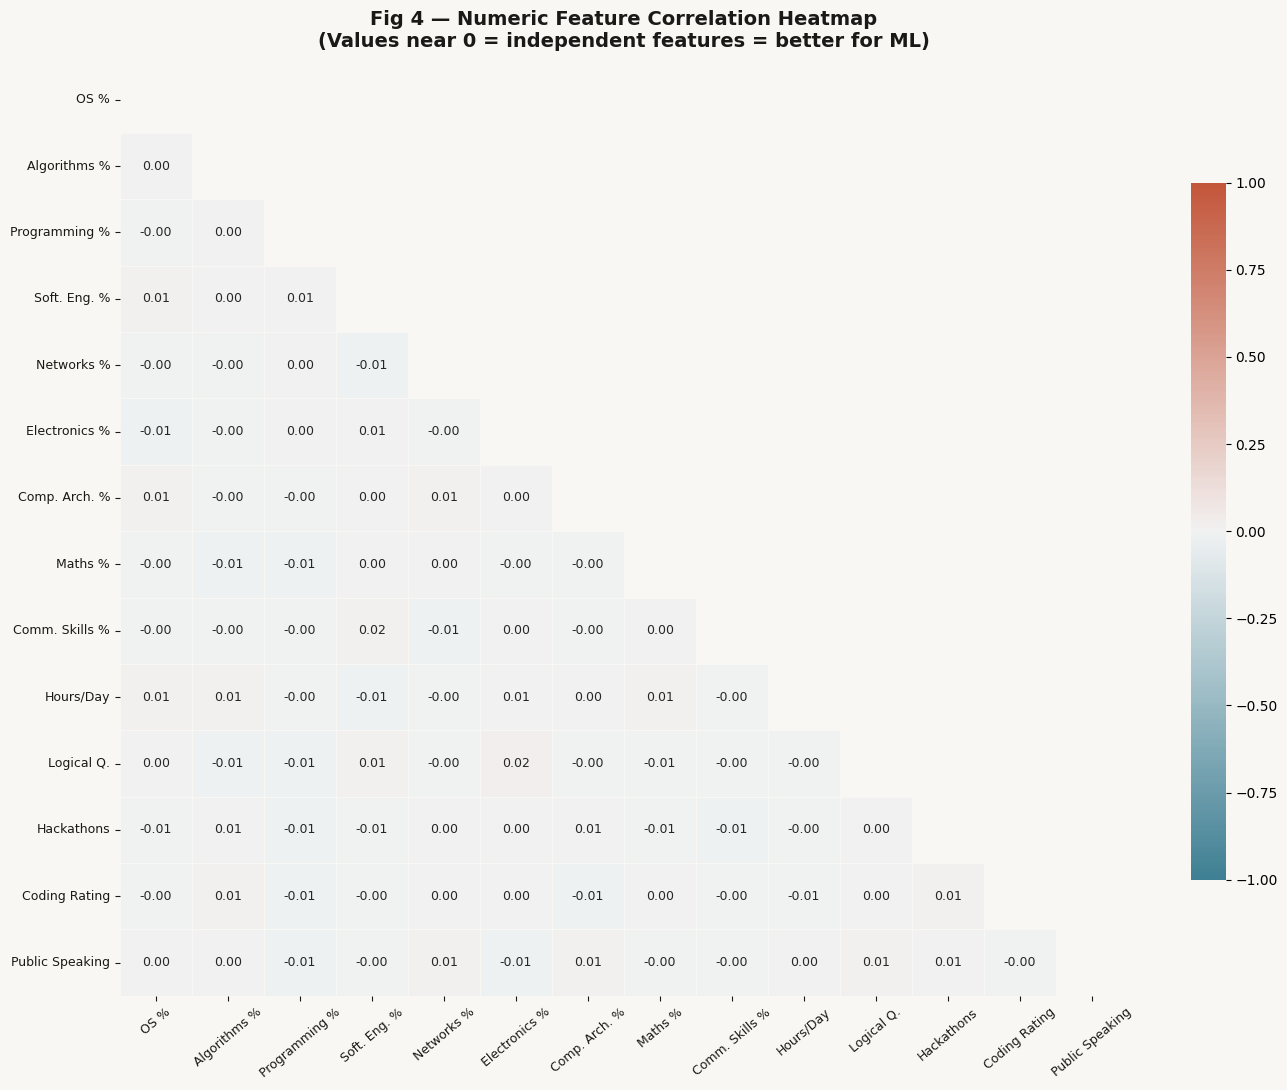

✅ No highly correlated feature pairs — all 14 numeric features are independent


In [7]:
corr = df[NUM_COLS].corr()
corr.index   = SHORT_NUM
corr.columns = SHORT_NUM
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
 
fig, ax = plt.subplots(figsize=(14, 11))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
 
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='#f8f7f4',
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'shrink': 0.75})
 
ax.set_title('Fig 4 — Numeric Feature Correlation Heatmap\n'
             '(Values near 0 = independent features = better for ML)',
             fontsize=14, fontweight='bold', color='#1a1917', pad=14)
ax.tick_params(axis='x', rotation=40, labelsize=9, colors='#1a1917')
ax.tick_params(axis='y', rotation=0,  labelsize=9, colors='#1a1917')
 
plt.tight_layout()
plt.savefig('Marks_dataset_eda/fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Print any high correlations found
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i):
        val = corr.iloc[i, j]
        if abs(val) > 0.5:
            high_corr.append((corr.columns[i], corr.columns[j], round(val, 3)))
 
if high_corr:
    print("⚠️  Pairs with correlation > 0.5:")
    for a, b, v in high_corr:
        print(f"   {a}  ↔  {b}  :  {v}")
else:
    print("✅ No highly correlated feature pairs — all 14 numeric features are independent")

## Mean Academic Score per Job Role:-

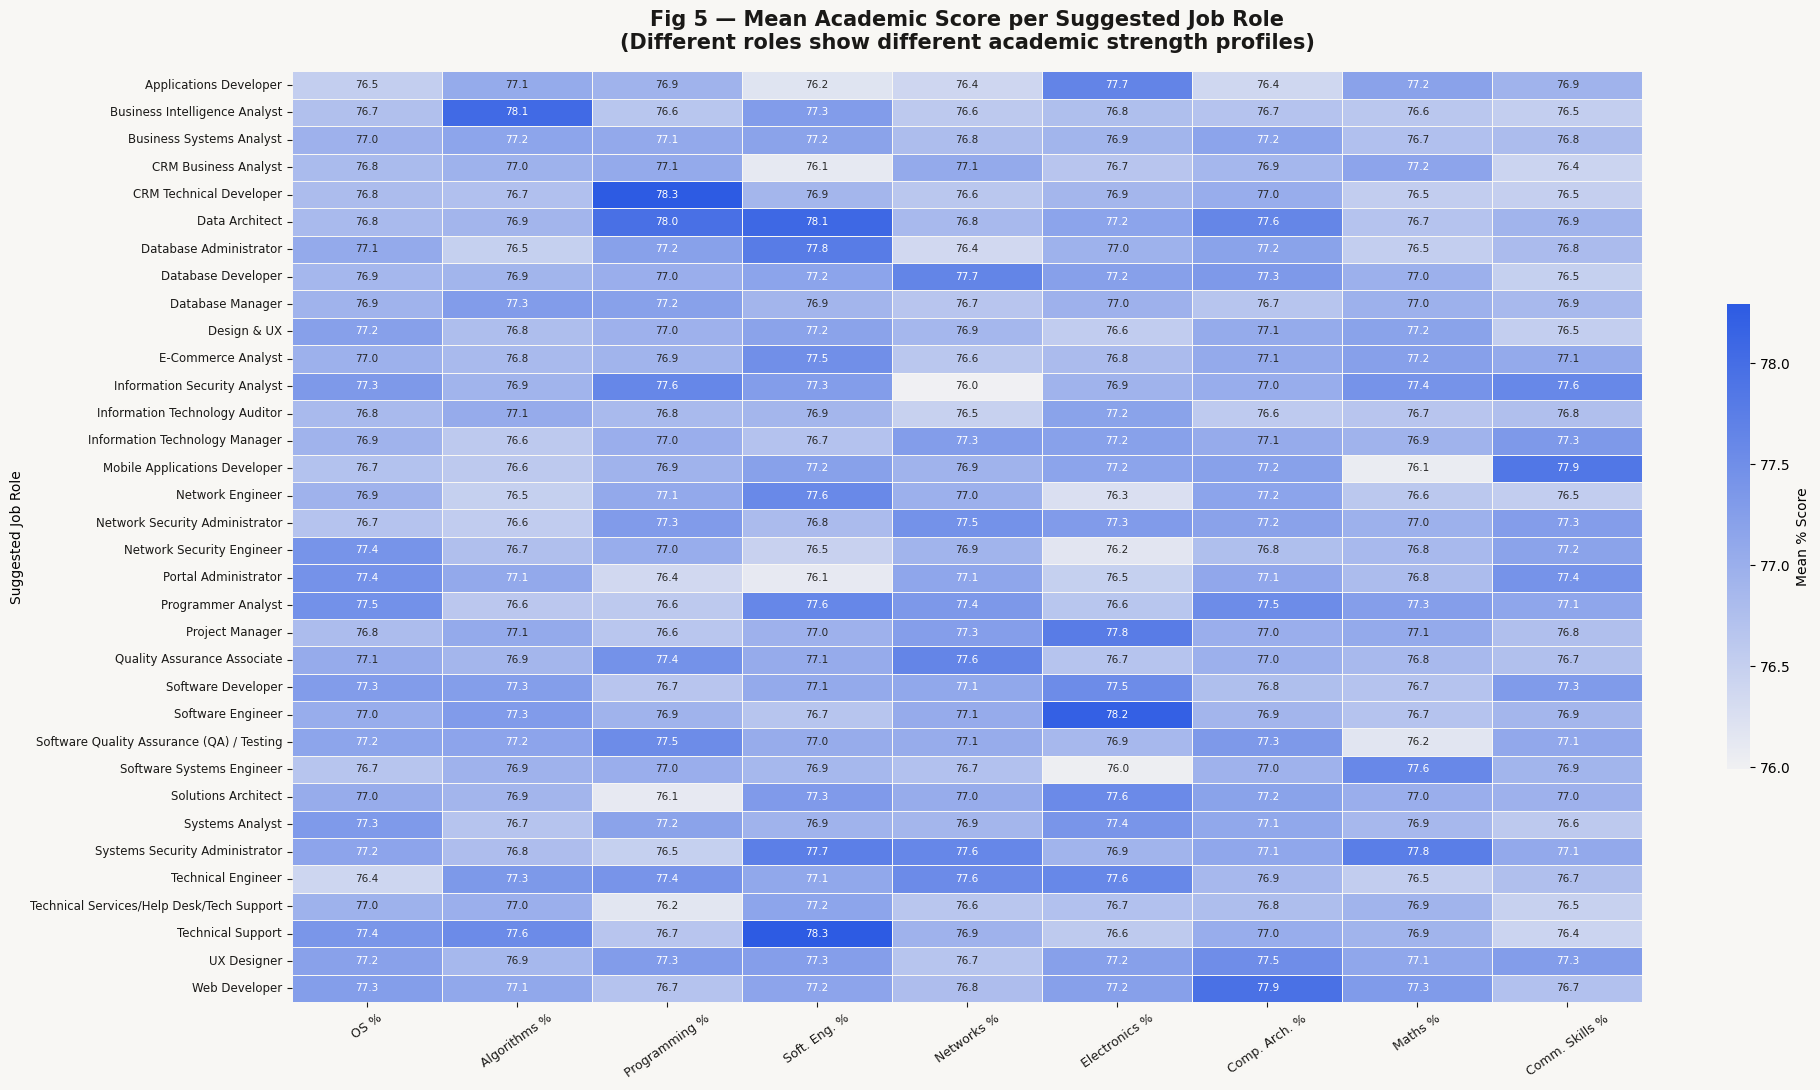

✅ Each job role has a distinct academic score profile — model has clear signal to learn


In [8]:
role_means = df.groupby(TARGET)[NUM_COLS[:9]].mean()
role_means.columns = SHORT_NUM[:9]
 
fig, ax = plt.subplots(figsize=(20, 11))
cmap2 = sns.light_palette('#2d5be3', as_cmap=True)
 
sns.heatmap(role_means, annot=True, fmt='.1f', cmap=cmap2,
            linewidths=0.4, linecolor='#f8f7f4',
            annot_kws={'size': 7.5}, ax=ax,
            cbar_kws={'shrink': 0.5, 'label': 'Mean % Score'})
 
ax.set_title('Fig 5 — Mean Academic Score per Suggested Job Role\n'
             '(Different roles show different academic strength profiles)',
             fontsize=15, fontweight='bold', color='#1a1917', pad=16)
ax.tick_params(axis='x', rotation=35, labelsize=9,  colors='#1a1917')
ax.tick_params(axis='y', rotation=0,  labelsize=8.5, colors='#1a1917')
 
plt.tight_layout()
plt.savefig('Marks_dataset_eda/fig5_role_means_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Each job role has a distinct academic score profile — model has clear signal to learn")
 

## Key Categorical Feature Distributions:-

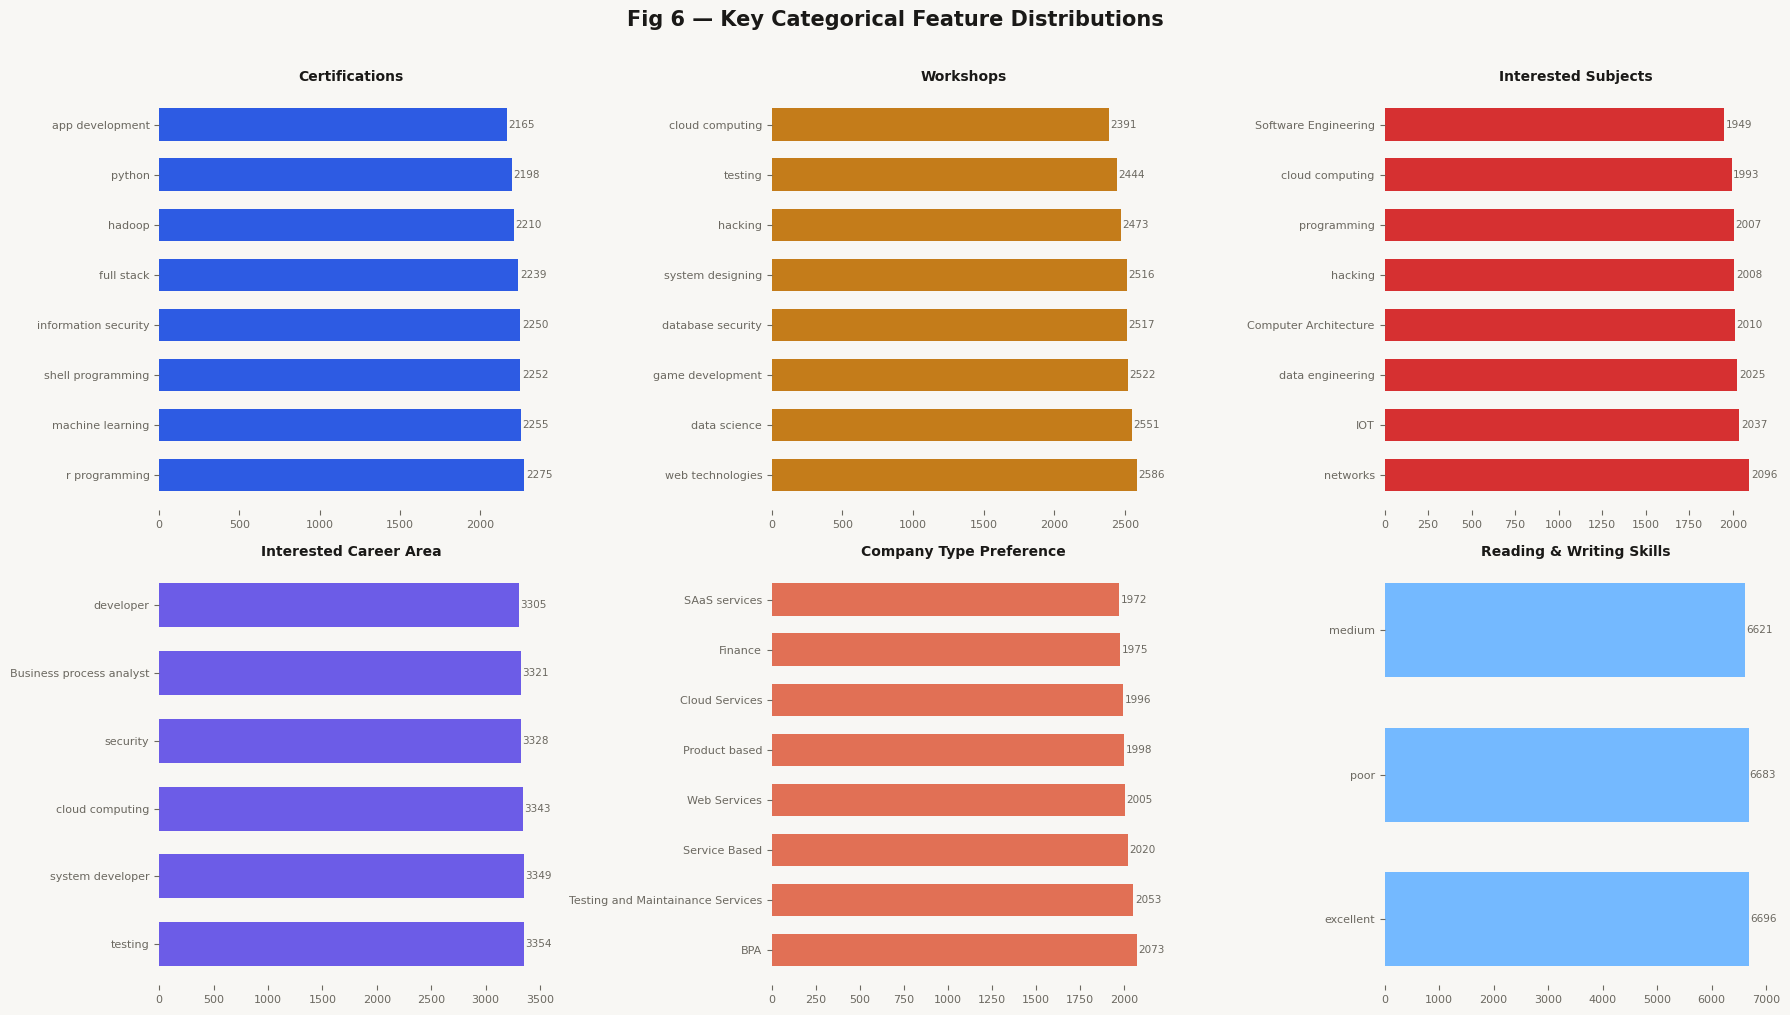

✅ All categorical features are evenly spread — no single category dominates


In [9]:
cat_cols_plot = [
    ('certifications',                    'Certifications'),
    ('workshops',                         'Workshops'),
    ('Interested subjects',               'Interested Subjects'),
    ('interested career area',            'Interested Career Area'),
    ('Type of company want to settle in?','Company Type Preference'),
    ('reading and writing skills',        'Reading & Writing Skills'),
]
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fig 6 — Key Categorical Feature Distributions',
             fontsize=15, fontweight='bold', color='#1a1917', y=1.01)
axes = axes.flatten()
 
for i, (col, label) in enumerate(cat_cols_plot):
    ax = axes[i]
    ax.set_facecolor('#f8f7f4')
    vc   = df[col].value_counts().head(8)
    bars = ax.barh(vc.index, vc.values,
                   color=PALETTE[i * 2 % len(PALETTE)],
                   edgecolor='none', height=0.65)
    for bar, val in zip(bars, vc.values):
        ax.text(val + 10, bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=7.5, color='#6b6860')
    ax.set_title(label, fontsize=10, fontweight='600', color='#1a1917', pad=6)
    ax.tick_params(labelsize=8, colors='#6b6860')
    ax.spines[['top','right','left','bottom']].set_visible(False)
 
plt.tight_layout()
plt.savefig('Marks_dataset_eda/fig6_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All categorical features are evenly spread — no single category dominates")

## Binary Feature Balance:-

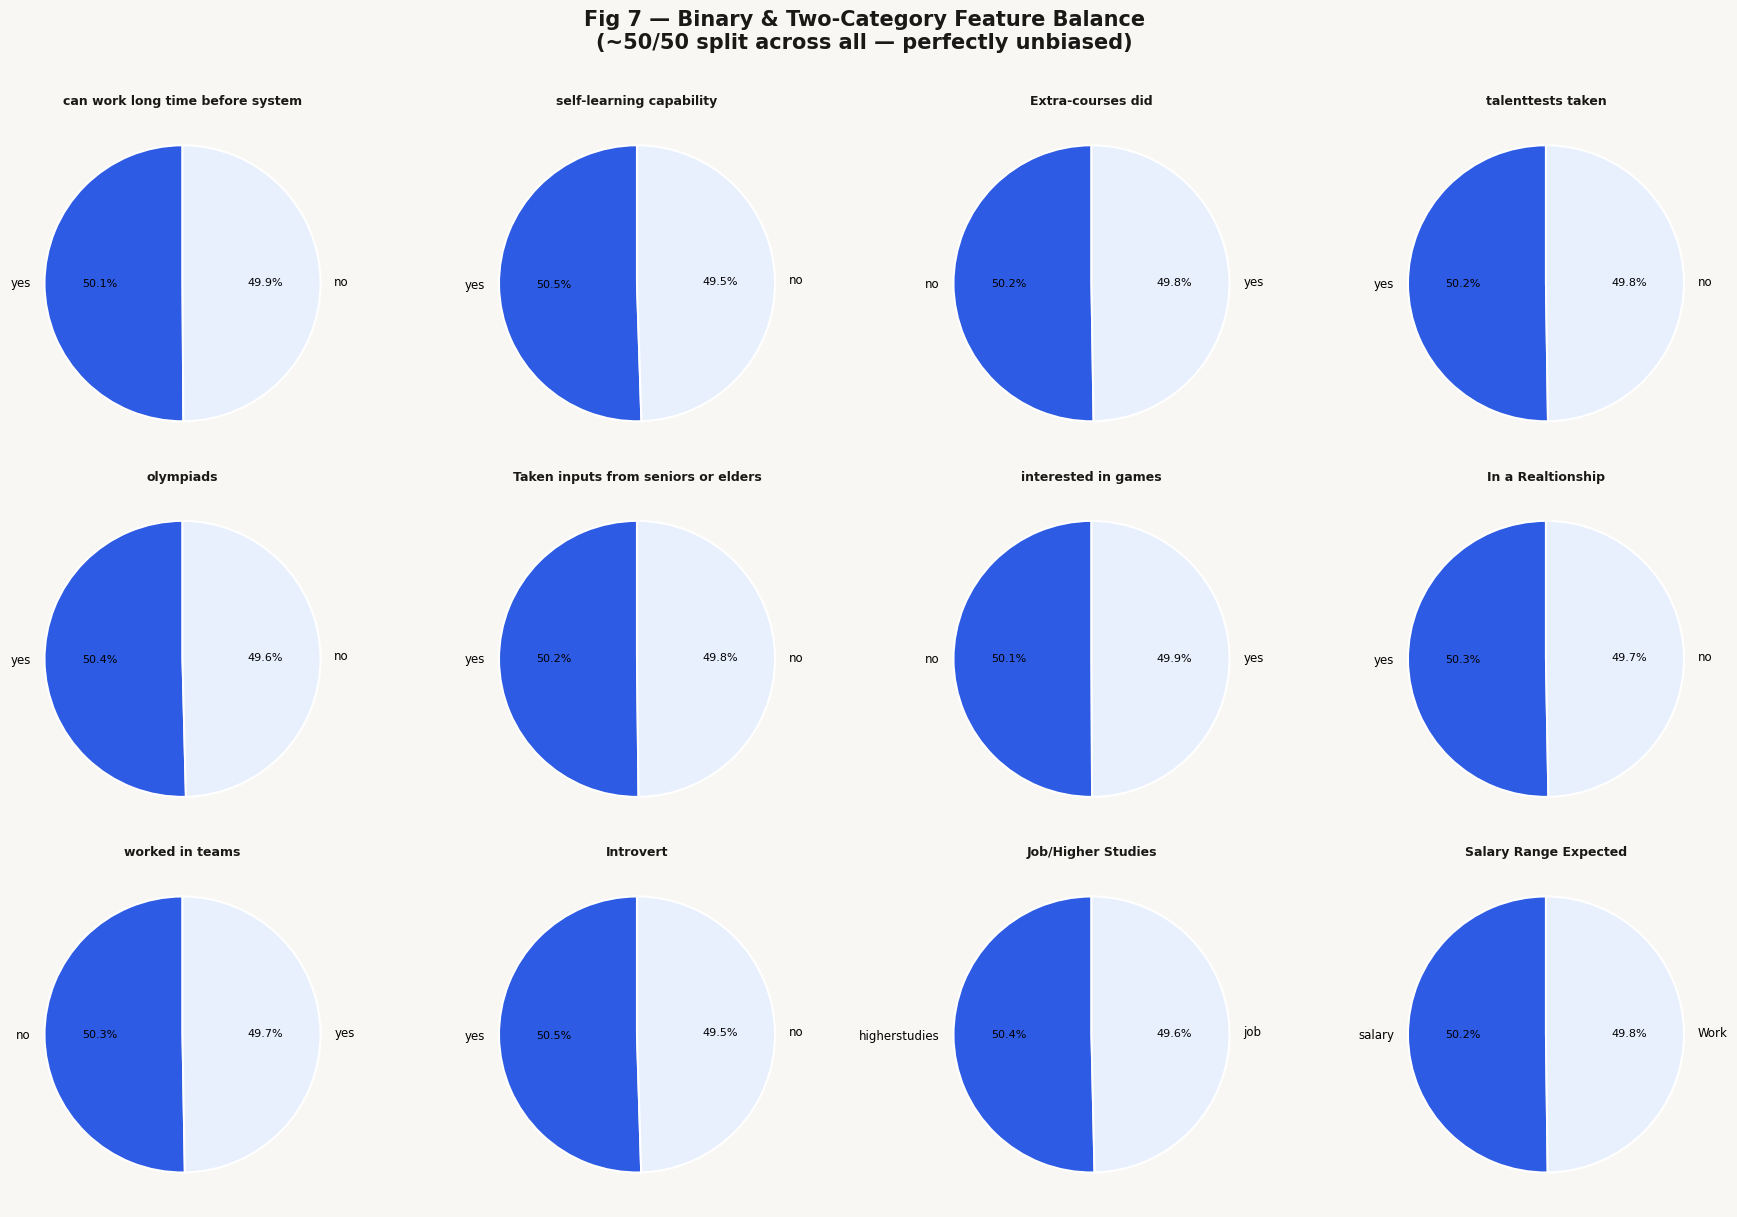

✅ All binary features are ~50/50 — zero hidden bias in yes/no columns


In [10]:
binary_cols = [
    'can work long time before system?',
    'self-learning capability?',
    'Extra-courses did',
    'talenttests taken?',
    'olympiads',
    'Taken inputs from seniors or elders',
    'interested in games',
    'In a Realtionship?',
    'worked in teams ever?',
    'Introvert',
    'Job/Higher Studies?',
    'Salary Range Expected',
]
 
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Fig 7 — Binary & Two-Category Feature Balance\n'
             '(~50/50 split across all — perfectly unbiased)',
             fontsize=15, fontweight='bold', color='#1a1917', y=1.01)
axes = axes.flatten()
 
for i, col in enumerate(binary_cols):
    ax   = axes[i]
    vc   = df[col].value_counts()
    cols_pie = ['#2d5be3', '#e8f0fe'] if len(vc) == 2 else PALETTE[:len(vc)]
    wedges, texts, autotexts = ax.pie(
        vc.values, labels=vc.index,
        colors=cols_pie,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 8.5},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for at in autotexts:
        at.set_fontsize(8)
    short = col.replace('?','').replace(' ever','').strip()
    ax.set_title(short, fontsize=9, fontweight='600', color='#1a1917', pad=4)
 
plt.tight_layout()
plt.savefig('Marks_dataset_eda/fig7_binary_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All binary features are ~50/50 — zero hidden bias in yes/no columns")
 

## Dataset Summary Stats Table:-

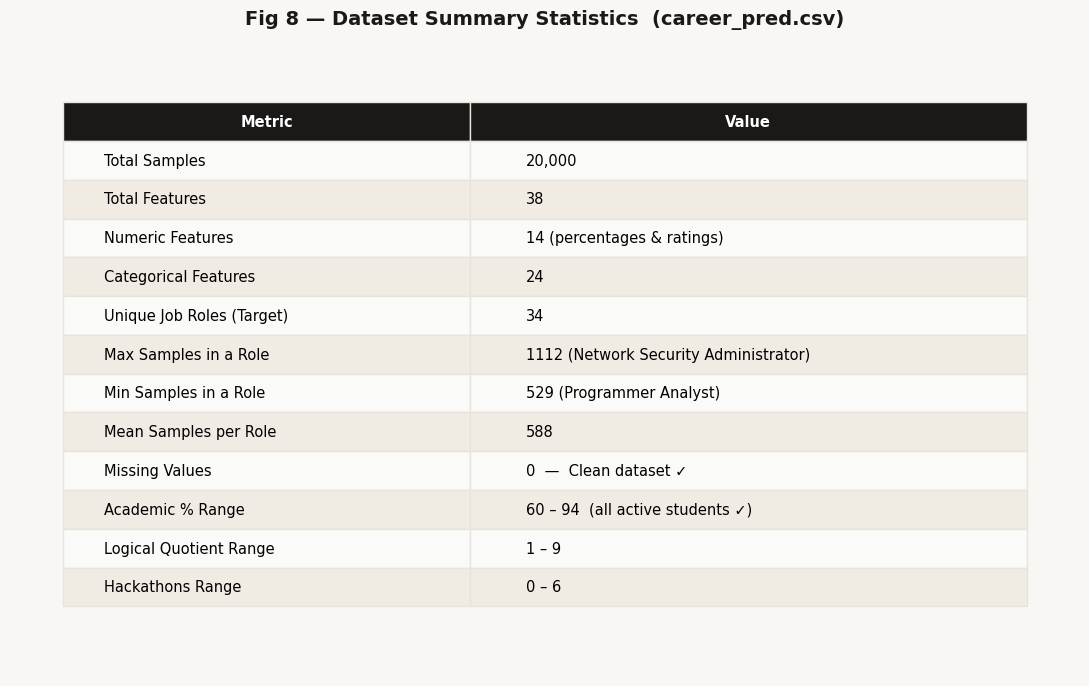

✅ All 8 figures generated and saved successfully!


In [11]:
role_vc = df[TARGET].value_counts()
 
fig, ax = plt.subplots(figsize=(11, 7))
ax.axis('off')
 
stats_data = [
    ['Total Samples',             f"{len(df):,}"],
    ['Total Features',            f"{len(df.columns) - 1}"],
    ['Numeric Features',          f"{len(NUM_COLS)} (percentages & ratings)"],
    ['Categorical Features',      f"{len(df.columns) - 1 - len(NUM_COLS)}"],
    ['Unique Job Roles (Target)', f"{df[TARGET].nunique()}"],
    ['Max Samples in a Role',     f"{role_vc.max()} ({role_vc.idxmax()})"],
    ['Min Samples in a Role',     f"{role_vc.min()} ({role_vc.idxmin()})"],
    ['Mean Samples per Role',     f"{role_vc.mean():.0f}"],
    ['Missing Values',            f"0  —  Clean dataset ✓"],
    ['Academic % Range',          '60 – 94  (all active students ✓)'],
    ['Logical Quotient Range',    '1 – 9'],
    ['Hackathons Range',          '0 – 6'],
]
 
table = ax.table(cellText=stats_data,
                 colLabels=['Metric', 'Value'],
                 cellLoc='left', loc='center',
                 colWidths=[0.38, 0.52])
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.95)
 
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#e8e4dc')
    if row == 0:
        cell.set_facecolor('#1a1917')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0ece4')
    else:
        cell.set_facecolor('#fafaf8')
 
ax.set_title('Fig 8 — Dataset Summary Statistics  (career_pred.csv)',
             fontsize=14, fontweight='bold', color='#1a1917', pad=20, y=0.97)
plt.tight_layout()
plt.savefig('Marks_dataset_eda/fig8_summary_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ All 8 figures generated and saved successfully!")